In [2]:
import numpy as np
from sys import path
from tqdm.auto import tqdm
from tqdm.contrib.concurrent import process_map
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pysr import PySRRegressor

path.append("../")

from src.train import perform_fold_prediction, run_dropout_estimation

Detected Jupyter notebook. Loading juliacall extension. Set `PYSR_AUTOLOAD_EXTENSIONS=no` to disable.


In this experiment, the objective is to perform symbolic regression, in a setting very similar to the ones proposed by Verdoja and Kyrki (2021). The steps are the following:
- A few synthetic datasets are created. The datasets contain only 1s as X, and a Gaussian distribution as y. Each dataset has a different Gaussian distribution, different number of samples and different dimensionality of the input. Divide these datasets into train-validation-test (possibly using cross validation, but we can start simple).
- Train a 1-layer MLP model on each dataset, with different configurations. The configurations are: dropout rate $p_d$; model precision $s$. The number of MCDropout iterations is fixed to $N = 10^6$, to simulate $ N \to \infty $.
- Run symbolic regression on the results obtained. At an initial stage, we can ignore the dataset characteristics, but later I should consider the dataset characteristics as well.
- Compare the symbolic regression results to the formula from Verdoja and Kyrki (2021):
$$
\mathrm{Var}[f] = \frac{K p_d(1-p_d)\overline y ^2}{(K - Kp_d + p_d)^2}
$$
where $K$ is the number of parameters in the model (corresponding to the dimendsionality of the input).

# Createing Synthetic Datasets

In [2]:
num_samples_in_dataset: int = 3200 + 2

dim_x: list[int] = [5, 10, 100, 500, 1000, 5000, 10000, 50000, 100000]
val_y: list[int] = [1,2, 10, 20, 50, 100, 500, 1000]

Xs = {dim: np.ones(shape=(num_samples_in_dataset, dim)) for dim in dim_x}
ys = {val: np.random.normal(loc=val, scale=1, size=num_samples_in_dataset) for val in val_y}

# get all combinations of x and y into a dictionary
datasets: dict[tuple[int, int], dict[str, tuple[np.ndarray, np.ndarray]]] = {
    (i, j): {
        "train": (x[: num_samples_in_dataset-1], y[: num_samples_in_dataset-1]),
        "val": (
            x[num_samples_in_dataset-1],
            y[num_samples_in_dataset-1],
        ),
        "test": (
            x[num_samples_in_dataset-2],
            y[num_samples_in_dataset-2],
        ),
    }
    for i, x in Xs.items()
    for j, y in ys.items()
}


datasets_val: dict[tuple[int, int], dict[str, tuple[np.ndarray, np.ndarray]]] = {
    (i, j): {
        "val": (x[: num_samples_in_dataset-1], y[: num_samples_in_dataset-1]),
    }
    for i, x in Xs.items()
    for j, y in ys.items()
}


The variable `datasets` contains the possible combinations that create unique datasets. A dataset is characterized by a specific input. Each dataset has `num_samples_in_dataset` values, which will be split evenly between a train, test and validation sets.

Below I plot an example of the obtained values, divided between train, validation and test. 

## Playing around a bit

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(datasets[0,3]["train"][1], label="train", alpha=0.3)
sns.histplot(datasets[0,3]["val"][1], label="val", alpha=0.3)
sns.histplot(datasets[0,3]["test"][1], label="test", alpha=0.3)
plt.legend()
plt.show()

KeyError: (0, 3)

In [147]:
# fai un for loop, richiama la funzione perform_fold_prediction e ottieni l'output dell'addestramento
# successivamente si deve poi chiamare la funzione che va a fare il calcolo dell'incertezza

K = 500
p = 0.01
y_mean = 10
example_dataset = datasets[(K,y_mean)]


classifier = perform_fold_prediction(
    x_train=example_dataset['train'][0].astype('float32'),
    y_train=example_dataset['train'][1].astype('float32'),
    x_val=example_dataset['val'][0],
    y_val=example_dataset['val'][1],
    name=(0,0),
    task_type="regression",
    output_size=1,
    model_args={"layer_size": 64,
                "hidden_activation_type": 'relu'},
    train_args={"num_epochs": 600},
    experiment_args={
        "alpha": 0.05,
        "num_layers": 0,
        "dropout_rate": p,
        "dropout_input": True,},
    x_test=example_dataset['test'][0],
    y_test=example_dataset['test'][1],
    random_seed=42,
    batch_size=16,
)

/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/notebooks/../src/train/__init__.py:188: UserWarning: METHOD NOT FINISHED TO IMPLEMENT. PLEASE CALCULATE PREDICTION METRICS FOR REGRESSION.
  warn(


In [148]:
x_val = example_dataset['val'][0]
num_mcdropout: int = int(1e5)
mc_predictions = np.asarray([classifier._predict(x_val.reshape(1, -1)) for _ in tqdm(range(num_mcdropout))])

  0%|          | 0/100000 [00:00<?, ?it/s]

In [149]:

print(f'Predicted y mean: {np.asarray(mc_predictions).mean()}')

print(f'Initial expected y mean: {y_mean}')
y_mean_changed = (y_mean * (1 - p)*K)/(K*(1-p) + p)
print(f'Changed (due to MCDroout) expected y mean: {y_mean_changed}')

print(f"Predicted variance: {np.asarray(mc_predictions).var()}")
y_var_changed = (K * p * (1 - p) * (y_mean**2)) / ((K - K * p + p) ** 2)
print(f"Changed (due to MCDroout) eaxpected variance: {y_var_changed}")

Predicted y mean: 10.204842566768685
Initial expected y mean: 10
Changed (due to MCDroout) expected y mean: 9.999797983879114
Predicted variance: 0.0027601076687867685
Changed (due to MCDroout) eaxpected variance: 0.0020201203983513695


<Axes: ylabel='Count'>

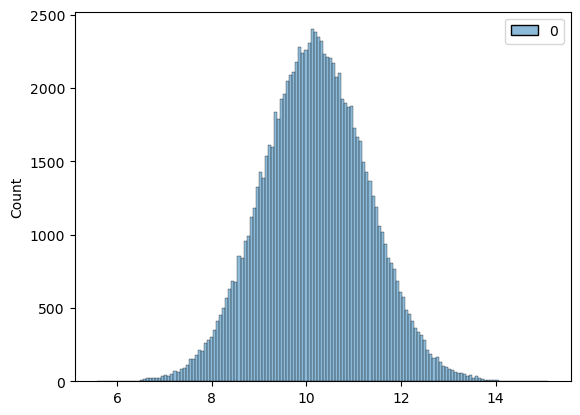

In [9]:
import seaborn as sns

sns.histplot(mc_predictions)

We managed to recreate the experiment from Verdoja. However, we also found that the uncertainty due to convergence can be large. In the context of our implementation, where the training is stopped automatically if there is minimal decrease ($<10^{-8}$) over a few epochs, this uncertainty can be controlled using the batch size. Hence, the larger the batch size, the larger the uncertianty. Below, I provide more empirical evidence of this. 

Note that the dependence of the batch size is only due to the fact that a larger batch size requires, technically, more epochs to reach the same convergence point. As such, the result should not be taken as "uncertainty depends on batch size", but "convergence uncertainty can be significantly higher than model uncertainty"

In [3]:
batch_sizes: list[int] = [1, 2, 4, 8, 16, 32, 48, 64, 80, 96, 112, 128, 144, 160, 176, 192, 208, 224, 240, 256, 272, 288, 304, 320, 336, 352, 368, 384, 400, 416, 432, 448, 464, 480, 496, 512, 1024, 2048]
variances: dict[int, float] = {}
for batch_size in tqdm(batch_sizes, desc="Batch sizes", colour="green", position=0):
    example_dataset = datasets[(0, 0)]

    classifier = perform_fold_prediction(
        x_train=example_dataset["train"][0].astype("float32"),
        y_train=example_dataset["train"][1].astype("float32"),
        x_val=example_dataset["val"][0],
        y_val=example_dataset["val"][1],
        name=(0, 0),
        task_type="regression",
        output_size=1,
        model_args={"layer_size": 64, "hidden_activation_type": "relu"},
        train_args={"num_epochs": 600},
        experiment_args={
            "alpha": 0.05,
            "num_layers": 0,
            "dropout_rate": 0.5,
            "dropout_input": True,
        },
        x_test=example_dataset["test"][0],
        y_test=example_dataset["test"][1],
        random_seed=42,
        batch_size=batch_size,
    )
    x_val = example_dataset["val"][0]
    num_mcdropout: int = int(1e5)
    mc_predictions = np.asarray(
        [classifier._predict(x_val.reshape(1, -1)) for _ in tqdm(range(num_mcdropout), leave=False, desc='MC Dropout', colour='blue', position=1)]
    )
    variances[batch_size] = np.asarray(mc_predictions).var()

Batch sizes:   0%|          | 0/38 [00:00<?, ?it/s]

/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/notebooks/../src/train/__init__.py:188: UserWarning: METHOD NOT FINISHED TO IMPLEMENT. PLEASE CALCULATE PREDICTION METRICS FOR REGRESSION.
  warn(


MC Dropout:   0%|          | 0/100000 [00:00<?, ?it/s]

/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/notebooks/../src/train/__init__.py:188: UserWarning: METHOD NOT FINISHED TO IMPLEMENT. PLEASE CALCULATE PREDICTION METRICS FOR REGRESSION.
  warn(


MC Dropout:   0%|          | 0/100000 [00:00<?, ?it/s]

...

MC Dropout:   0%|          | 0/100000 [00:00<?, ?it/s]

/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/notebooks/../src/train/__init__.py:188: UserWarning: METHOD NOT FINISHED TO IMPLEMENT. PLEASE CALCULATE PREDICTION METRICS FOR REGRESSION.
  warn(


MC Dropout:   0%|          | 0/100000 [00:00<?, ?it/s]

/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/notebooks/../src/train/__init__.py:188: UserWarning: METHOD NOT FINISHED TO IMPLEMENT. PLEASE CALCULATE PREDICTION METRICS FOR REGRESSION.
  warn(


MC Dropout:   0%|          | 0/100000 [00:00<?, ?it/s]

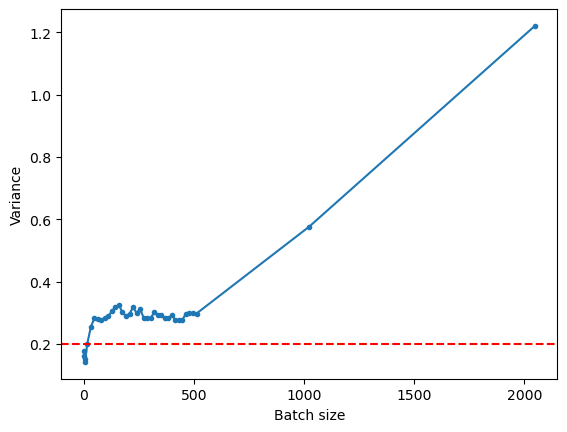

In [10]:
# plot the variances as a function of the batch size
plt.plot(variances.keys(), variances.values(), marker='.')
plt.xlabel("Batch size")
plt.ylabel("Variance")
plt.axhline(y=y_var_changed, color='r', linestyle='--')
plt.show()

-------

# Symbolic regression

Actual implementation of symbolic regression, to see if I get the correct formula. Given the experiment above, I will use a small batch size with stopping of training based on the loss.

In [ ]:
# NOTE: I am using the same dropout rates as I plan later
dropouts = [0.001, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9]
num_mcdropout: int = int(1e5)
variances_dropout: dict[tuple[int, int, float], float] = {}

for (K, y_mean), dataset in tqdm(datasets.items(), desc='Dataset progress'):
    for p in dropouts:
        classifier = perform_fold_prediction(
            x_train=dataset["train"][0].astype("float32"),
            y_train=dataset["train"][1].astype("float32"),
            x_val=dataset["val"][0],
            y_val=dataset["val"][1],
            name=(0, 0),
            task_type="regression",
            output_size=1,
            model_args={"layer_size": 64, "hidden_activation_type": "relu"},
            train_args={"num_epochs": 600},
            experiment_args={
                "alpha": 0.05,
                "num_layers": 0,
                "dropout_rate": p,
                "dropout_input": True,
            },
            x_test=dataset["test"][0],
            y_test=dataset["test"][1],
            random_seed=42,
            batch_size=16,
        )
        x_val = dataset["val"][0]
        mc_predictions = np.asarray(
            [
                classifier._predict(x_val.reshape(1, -1))
                for _ in tqdm(range(num_mcdropout), leave=False)
            ]
        )
        variances_dropout[(K, y_mean, p)] = np.asarray(mc_predictions).var()

Dataset progress:   0%|          | 0/36 [00:00<?, ?it/s]

/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/notebooks/../src/train/__init__.py:188: UserWarning: METHOD NOT FINISHED TO IMPLEMENT. PLEASE CALCULATE PREDICTION METRICS FOR REGRESSION.
  warn(


  0%|          | 0/100000 [00:00<?, ?it/s]

/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/notebooks/../src/train/__init__.py:188: UserWarning: METHOD NOT FINISHED TO IMPLEMENT. PLEASE CALCULATE PREDICTION METRICS FOR REGRESSION.
  warn(


  0%|          | 0/100000 [00:00<?, ?it/s]

...

  0%|          | 0/100000 [00:00<?, ?it/s]

/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/notebooks/../src/train/__init__.py:188: UserWarning: METHOD NOT FINISHED TO IMPLEMENT. PLEASE CALCULATE PREDICTION METRICS FOR REGRESSION.
  warn(


  0%|          | 0/100000 [00:00<?, ?it/s]

/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/notebooks/../src/train/__init__.py:188: UserWarning: METHOD NOT FINISHED TO IMPLEMENT. PLEASE CALCULATE PREDICTION METRICS FOR REGRESSION.
  warn(


  0%|          | 0/100000 [00:00<?, ?it/s]

In [ ]:
regression_data = pd.DataFrame.from_dict(variances_dropout, orient='index')
regression_data.index = pd.MultiIndex.from_tuples(regression_data.index, names=['K', 'y_mean', 'p'])
regression_data = regression_data.reset_index(inplace=False)
regression_data = regression_data.rename(columns={0: "variance"}, inplace=False)

In [ ]:
regression_data.to_csv("./symbolic_regression_verdoja/uncertainty_data.csv", )

In [3]:
regression_data = pd.read_csv("./symbolic_regression_verdoja/uncertainty_data.csv")

In [ ]:
model = PySRRegressor(
        niterations=2000,  # < Increase me for better results
        populations=100,
        binary_operators=["+", "-", "*", "/",],
                        #   "^"],
        unary_operators=[
            # "inv(x) = 1/x",
            # ^ Custom operator (julia syntax)
            "square",
            # "cube",
            # "exp",
            # "abs",
            # "log",
            # "log10",
            # "log2",
            # "log1p",
            # "sqrt",
        ],
        random_state=42,
        procs=-1,
        multithreading=True,
        batching=True,
        temp_equation_file=True,
        tempdir="./symbolic_regression_verdoja",
        delete_tempfiles=False,
        turbo=True,
        # equation_file=os.path.join(path_to_save, f"equation_{outer_fold}.csv"),
    )
model.fit(regression_data[['K', 'y_mean', 'p']].values, regression_data[['variance']].values)

/Users/leonardoalchieri/mambaforge/envs/mcdropout/lib/python3.12/site-packages/pysr/sr.py:1258: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
/Users/leonardoalchieri/mambaforge/envs/mcdropout/lib/python3.12/site-packages/pysr/sr.py:1309: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/leonardoalchieri/mambaforge/envs/mcdropout/lib/python3.12/site-packages/pysr/sr.py:65: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.790e+05
Head worker occupation: 8.7%
Progress: 637 / 30000 total iterations (2.123%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           2.595e+08  1.594e+01  y = x₁
2           2.470e+08  4.915e-02  y = cube(16.77)
3           1.848e+08  2.904e-01  y = x₁ / 0.051241
4           1.844e+08  1.697e-03  y = square(x₁ * 0.14239)
5           1.235e+08  4.008e-01  y = (x₂ * x₁) ^ 1.5347
7           1.113e+08  5.239e-02  y = (cube(sqrt(x₁)) * 1.4814) * x₂
9           1.034e+08  3.644e-02  y = (x₂ * x₁) / ((x₀ / x₁) ^ 0.79728)
10          4.663e+07  7.965e-01  y = (x₁ * x₂) / ((sqrt(x₀) / 676.2) ^ 0.79728)
12          2.764e+07  2.615e-01  y = x₁ / (cube(((x₀ / x₁) + 0.70205) * 0.32672) / x₂)
14          2.763e+07  2.183e-04  y = (x₁ + 1.0634) / (cube(((x₀ / x₁) + 0.70205) * 0.32672) / x...
                                  ₂)
15          2.76

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          4608.2153   
	1         0.000002                                     cube(16.66243)   
	2         0.296115                                     x1 ^ 1.4191171   
	3         0.000637                            cube(x1) * 1.8410203e-5   
	4         0.522203                                (x1 * x2) ^ 1.59583   
	5         0.002603                        (x2 * x1) ^ cube(1.1667011)   
	6         0.078529                        ((x2 * 528.4616) * x1) / x0   
	7         0.062703                 ((x1 / sqrt(x0)) ^ 1.8835938) * x2   
	8         0.547224           sqrt((x1 ^ square(1.8835938)) / x0) * x2   
	9         0.542697           x1 / (cube(0.22163863 + (x0 / x1)) / x2)   
	10        0.302697   x1 / ((square(x0 / x1) + cube(0.22163863)) / x2)   
	11        0.041309  x1 / (((square(x0 / x1) / x2) + cube(0.2216386...   
	12        0.024087  x1 / (cube(0.32672444 * (0.67290175 + ((x0 / x...   
	13        0.040238  x1 / ((cube(0.22163863) + (square(x0 / (x0 + x...   
	14        0.084231  x1 / ((0.32672444 * (square(1.0242083 / x0) + ...   
	15        0.661534  x1 / ((0.55063826 * (cube(0.22486562 + (x0 / x...   
	16  >>>>  0.238471  x1 / ((0.5478582 * (cube(0.22163863 + ((x0 / x...   
	
	           loss  complexity  
	0   247007410.0           1  
	1   247007020.0           2  
	2   183699540.0           3  
	3   183582500.0           4  
	4   108903350.0           5  
	5   108620230.0           6  
	6   100416740.0           7  
	7    94313640.0           8  
	8    54565500.0           9  
	9    31712310.0          10  
	10   23429792.0          11  
	11   21571868.0          13  
	12   21058470.0          14  
	13   20227940.0          15  
	14   18593898.0          16  
	15    9595553.0          17  
	16    5955749.5          19  
]

In [ ]:
regression_data["variance_verdoja"] = regression_data[["K", "y_mean", "p"]].apply(
    lambda x: (x[0] * x[2] * (1 - x[2]) * (x[1] ** 2))
    / ((x[0] - x[0] * x[2] + x[2]) ** 2),
    axis=1,
)
regression_data["our_formula"] = regression_data[["K", "y_mean", "p"]].apply(
    lambda x: model.predict(x.values.reshape(1, -1))[0], 
        # (x[1])**2 / (((x[0] + (1.8603)**2) / x[2]) - x[0]),
    axis=1,
)

/var/folders/rc/t3h_b88s3vbg5dcd4pnlgskr0000gp/T/ipykernel_92827/3949543242.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: (x[0] * x[2] * (1 - x[2]) * (x[1] ** 2))
/var/folders/rc/t3h_b88s3vbg5dcd4pnlgskr0000gp/T/ipykernel_92827/3949543242.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  / ((x[0] - x[0] * x[2] + x[2]) ** 2),


In [ ]:
regression_data.to_csv("./symbolic_regression_verdoja/uncertainty_data_with_formulas_2.csv", )

In [3]:
regression_data = pd.read_csv("/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/experiments/verdojas_equation/results.nosync/3bfa00736cece5870b228a968e699c39/regression_data_with_equations_test.csv")

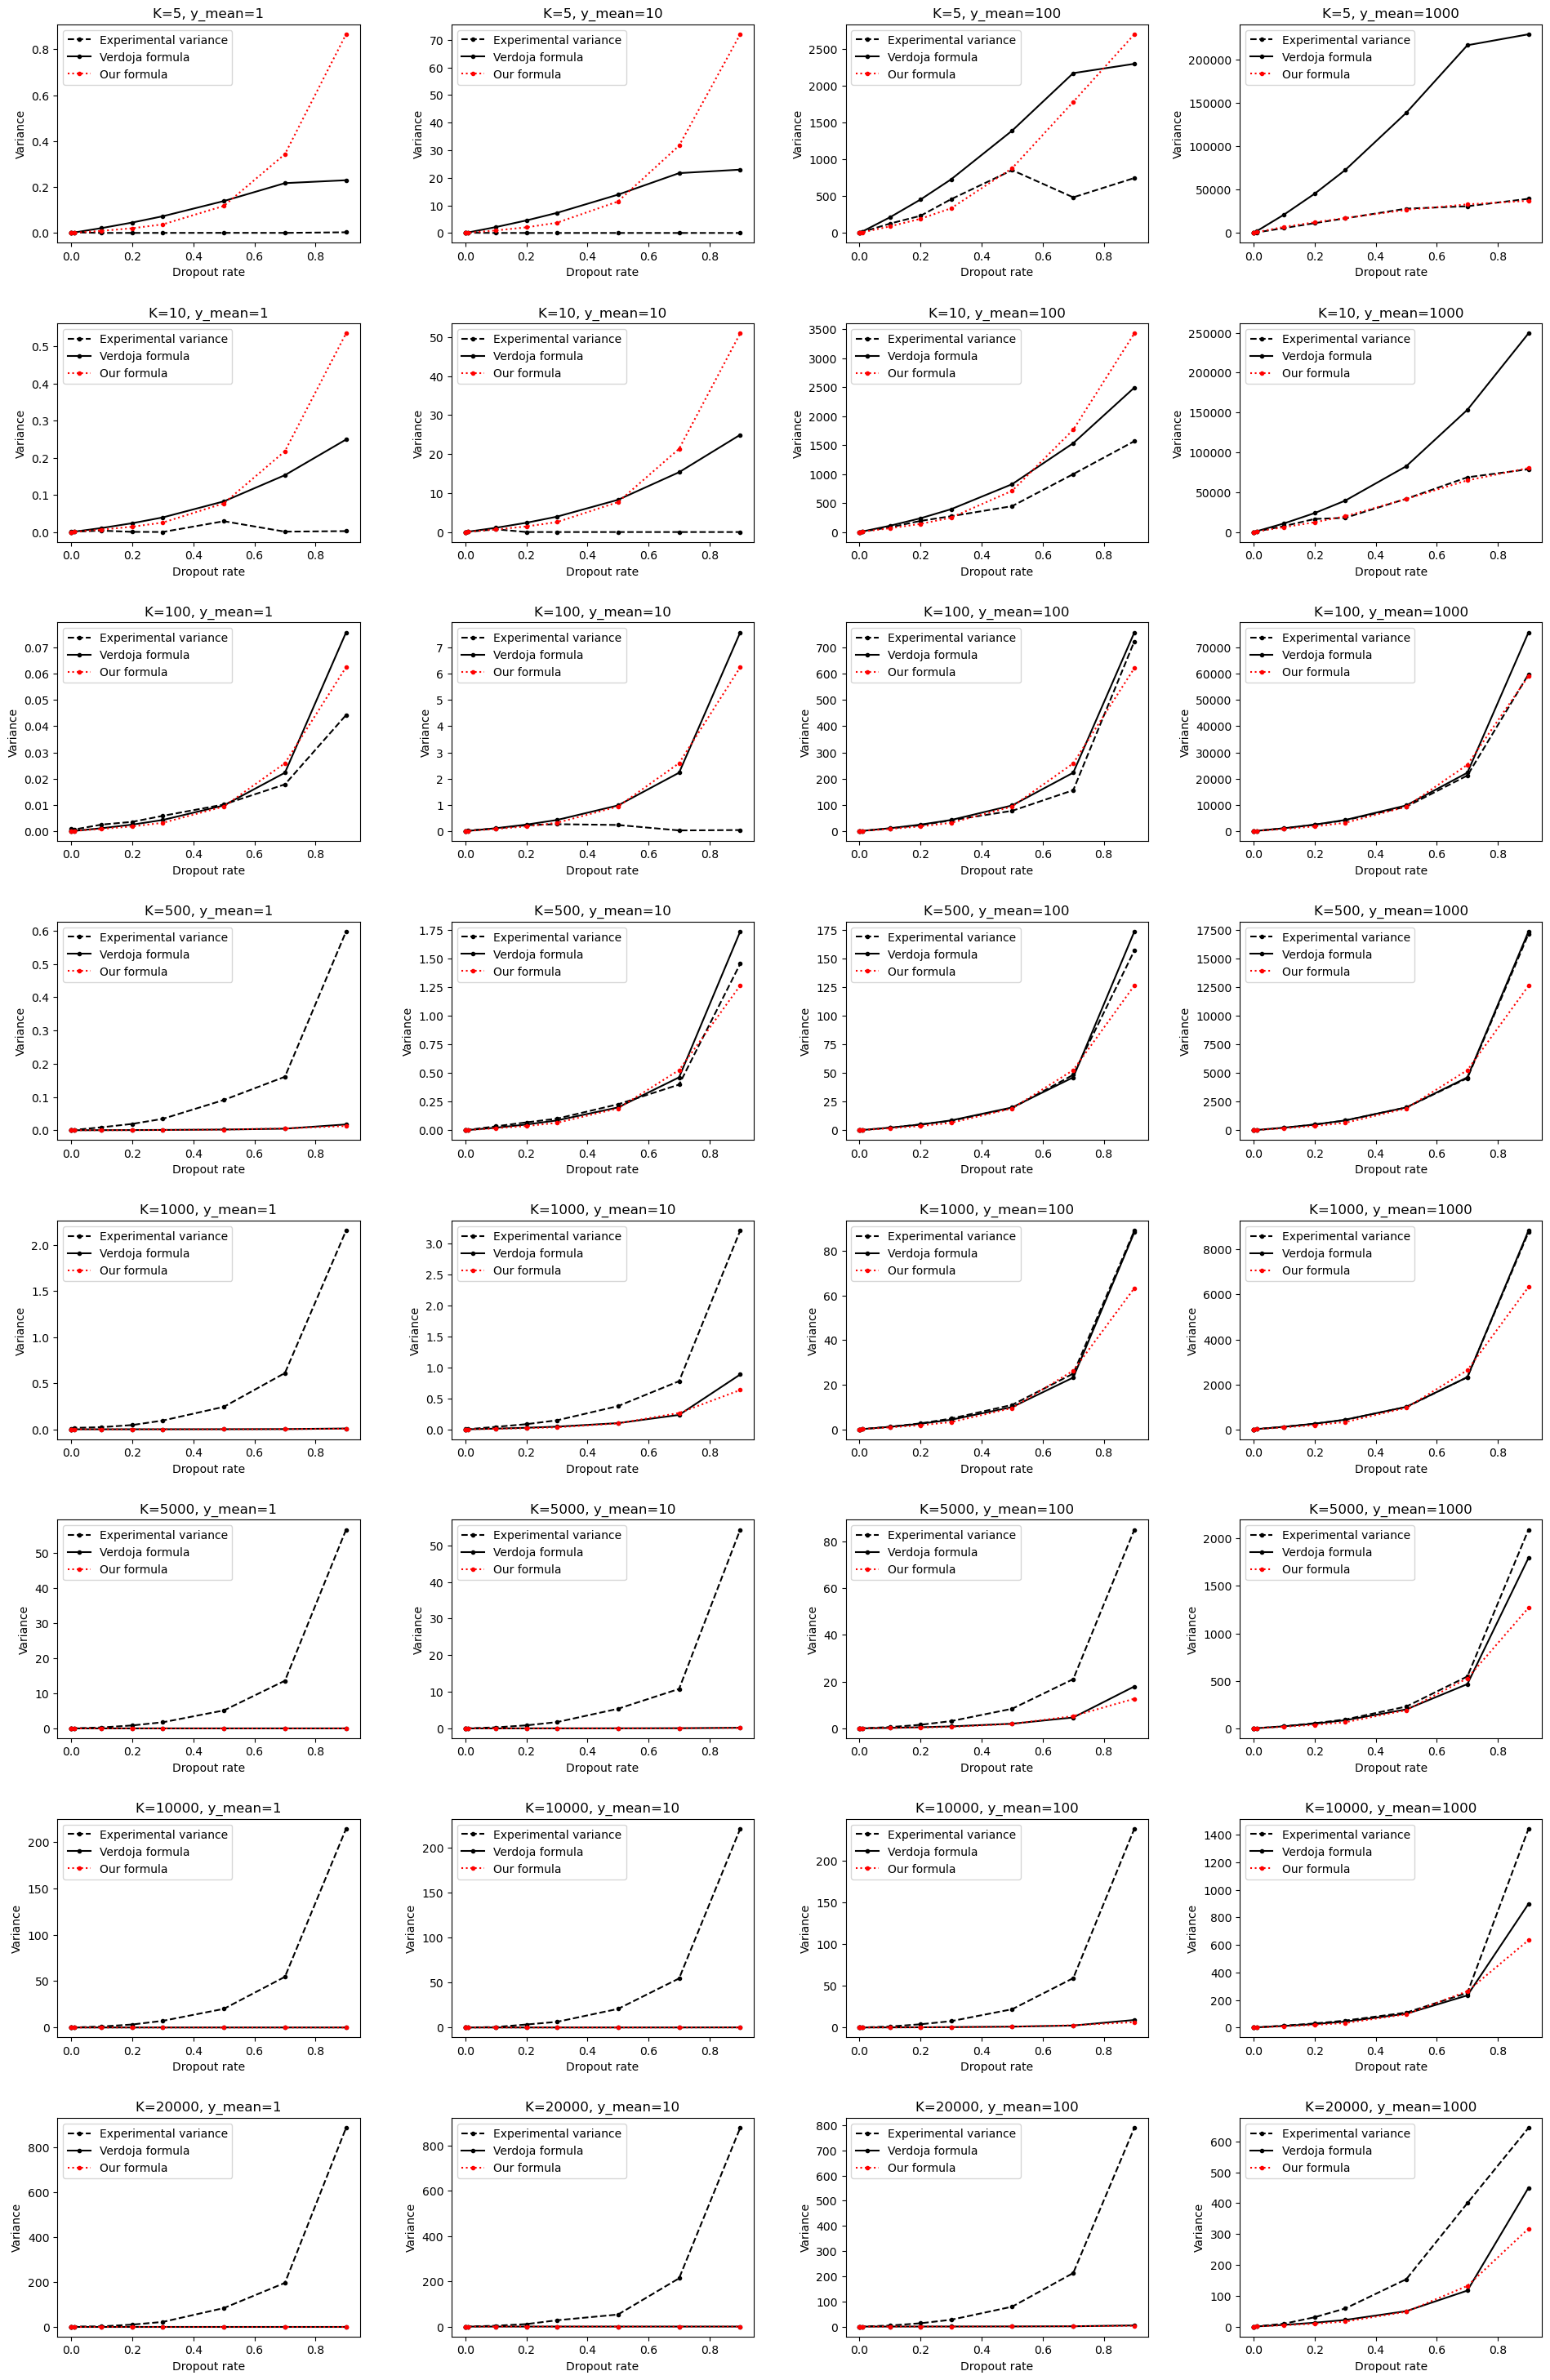

In [5]:
from pyparsing import line


fig, axes = plt.subplots(nrows=len(regression_data["K"].unique()), ncols=len(regression_data["y_mean"].unique()), figsize=(20, 30))
fig.tight_layout(pad=5.0)

for i, K in enumerate(regression_data["K"].unique()):
    for j, y_mean in enumerate(regression_data["y_mean"].unique()):
        data_to_plot = regression_data[
            (regression_data["K"] == K) & (regression_data["y_mean"] == y_mean)
        ]
        x = data_to_plot["p"]
        y = data_to_plot["variance"]
        y_verdoja = data_to_plot["variance_verdoja"]
        y_our_formula = data_to_plot["our_formula"]

        ax = axes[i, j]
        ax.plot(x, y, label="Experimental variance", marker=".", linestyle="--", color='black')
        ax.plot(x, y_verdoja, label="Verdoja formula", marker=".", linestyle="-", color='black')
        ax.plot(x, y_our_formula, label="Our formula", marker=".", linestyle=":", color='red')
        ax.set_xlabel("Dropout rate")
        ax.set_ylabel("Variance")
        ax.set_title(f"K={K}, y_mean={y_mean}")
        ax.legend()
plt.savefig("./symbolic_regression_verdoja/uncertainty_comparison_symbolic.pdf", bbox_inches='tight')
plt.show()


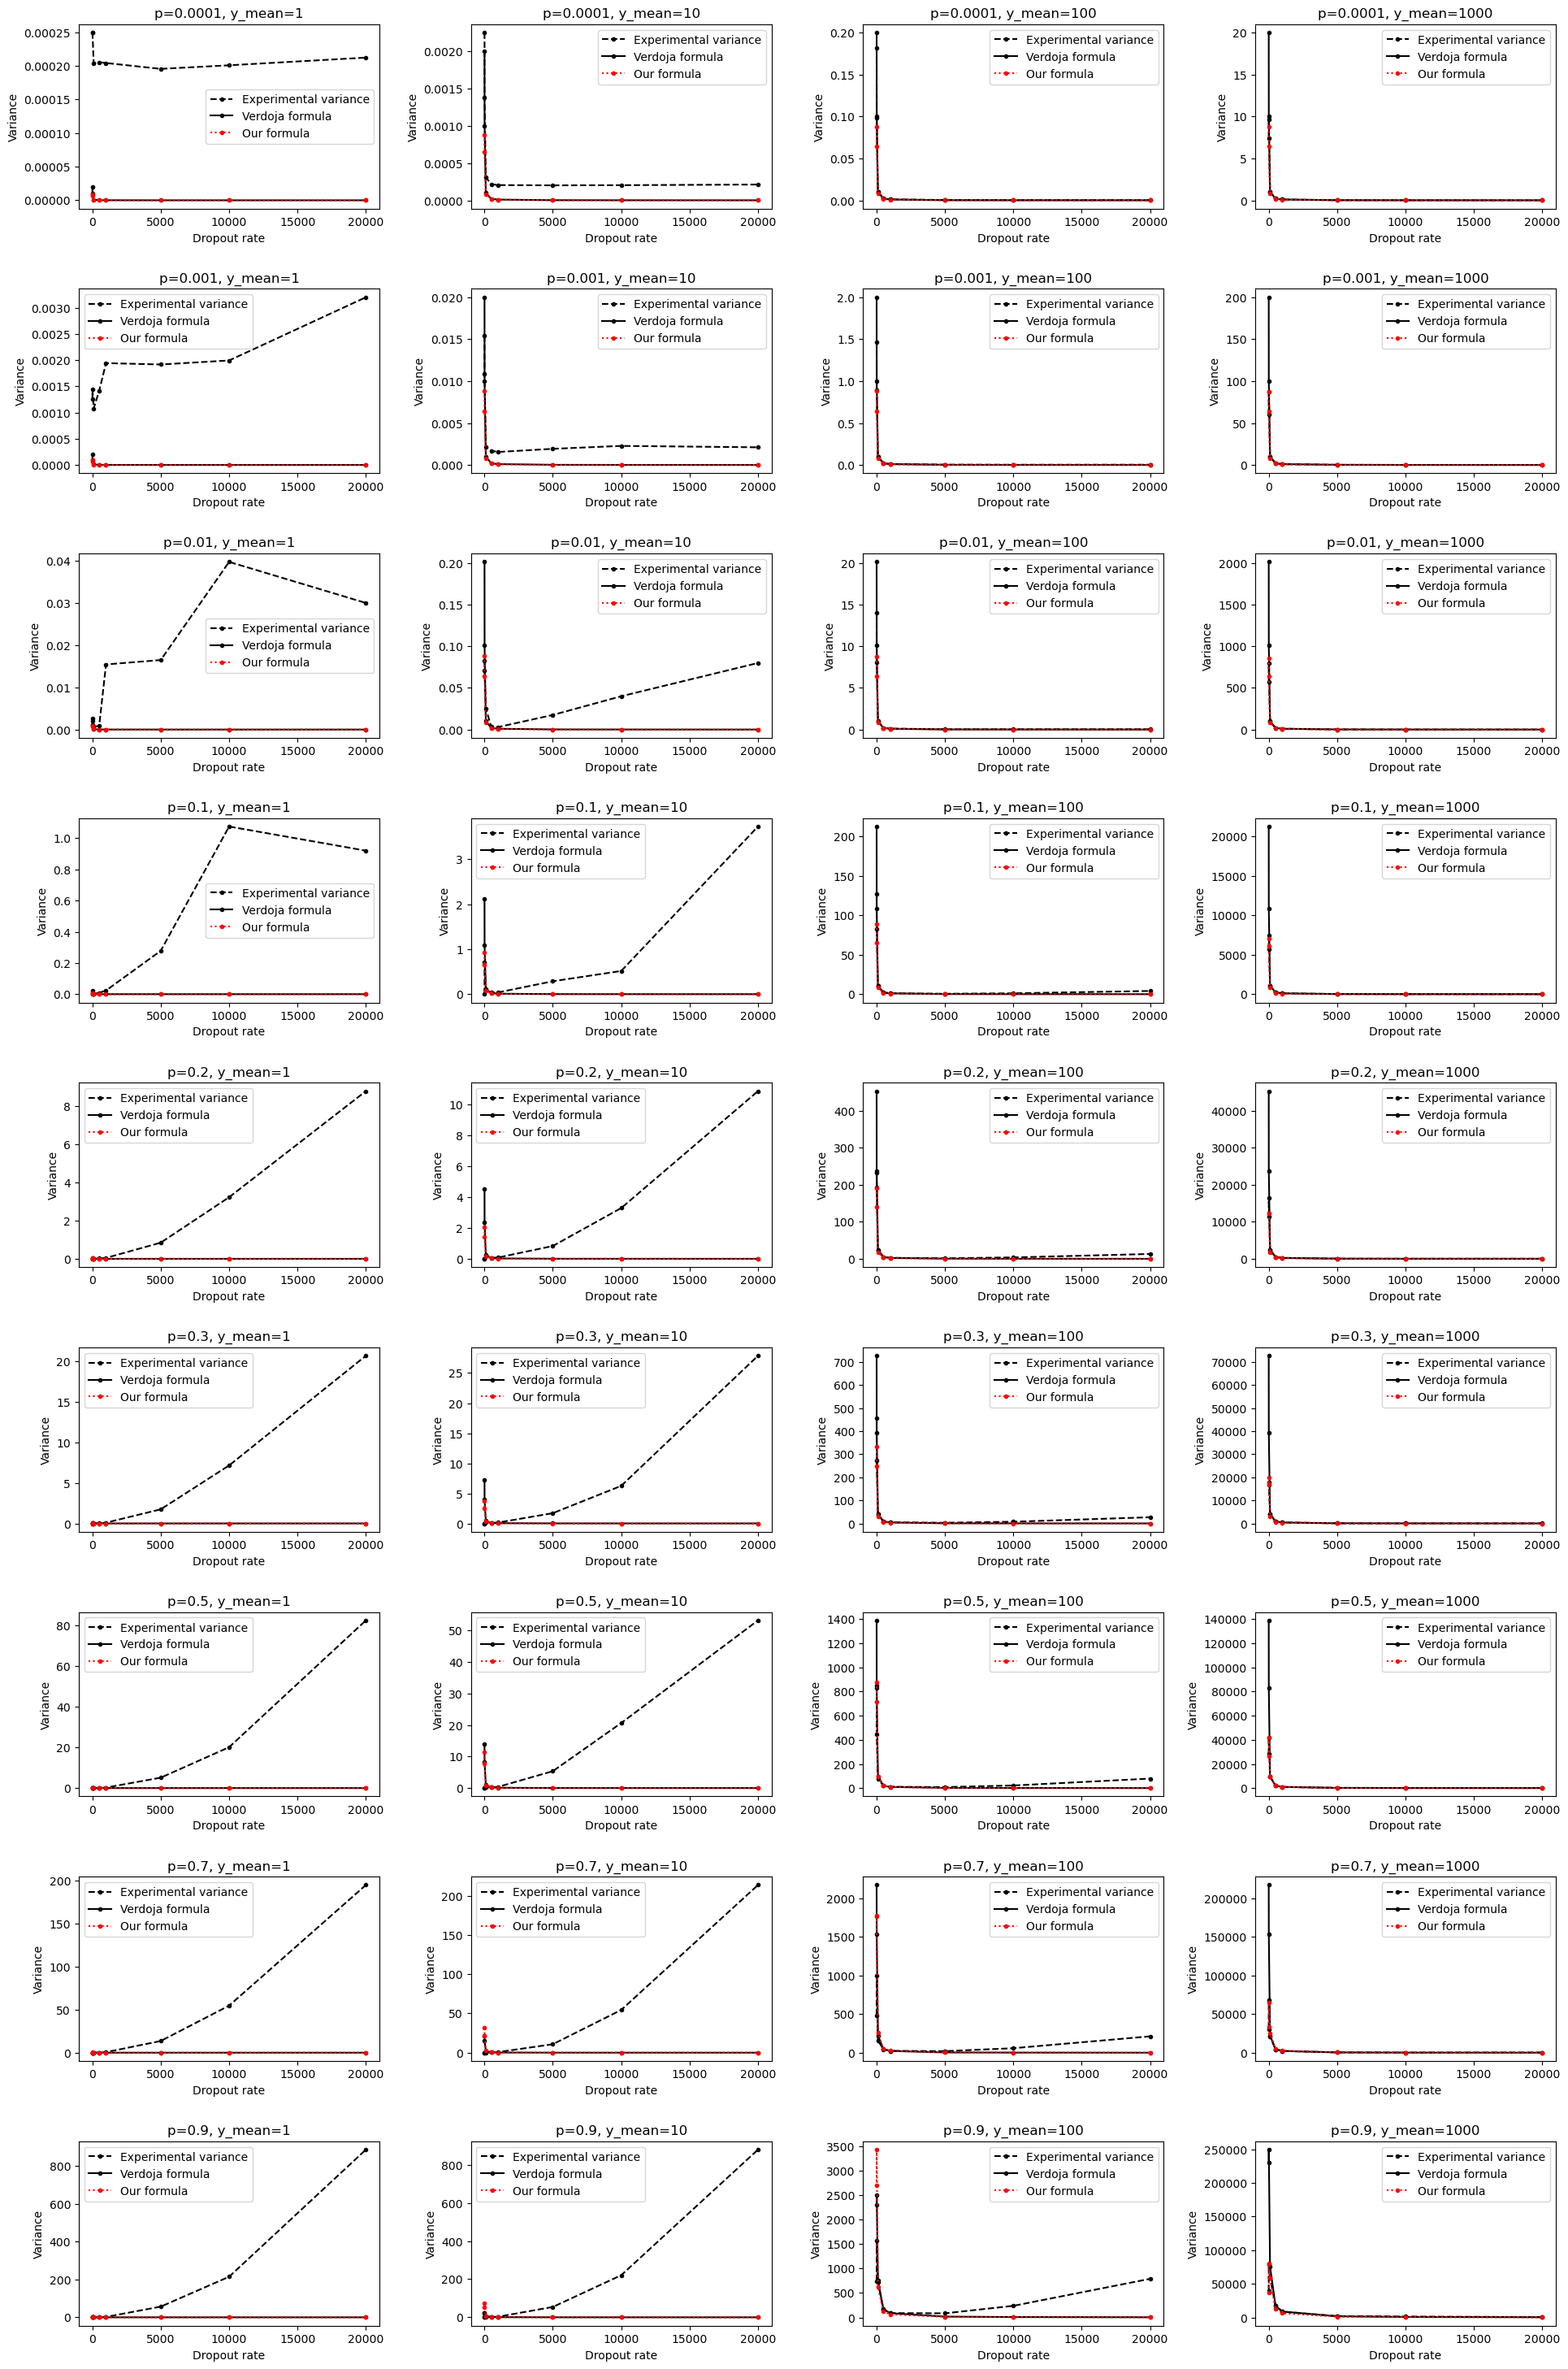

In [6]:
from pyparsing import line


fig, axes = plt.subplots(nrows=len(regression_data["p"].unique()), ncols=len(regression_data["y_mean"].unique()), figsize=(20, 30))
fig.tight_layout(pad=5.0)

for i, p in enumerate(regression_data["p"].unique()):
    for j, y_mean in enumerate(regression_data["y_mean"].unique()):
        data_to_plot = regression_data[
            (regression_data["p"] == p) & (regression_data["y_mean"] == y_mean)
        ]
        x = data_to_plot["K"]
        y = data_to_plot["variance"]
        y_verdoja = data_to_plot["variance_verdoja"]
        y_our_formula = data_to_plot["our_formula"]

        ax = axes[i, j]
        ax.plot(x, y, label="Experimental variance", marker=".", linestyle="--", color='black')
        ax.plot(x, y_verdoja, label="Verdoja formula", marker=".", linestyle="-", color='black')
        ax.plot(x, y_our_formula, label="Our formula", marker=".", linestyle=":", color='red')
        ax.set_xlabel("Dropout rate")
        ax.set_ylabel("Variance")
        ax.set_title(f"p={p}, y_mean={y_mean}")
        ax.legend()
plt.savefig("./symbolic_regression_verdoja/uncertainty_comparison_symbolic_K.pdf", bbox_inches='tight')
plt.show()


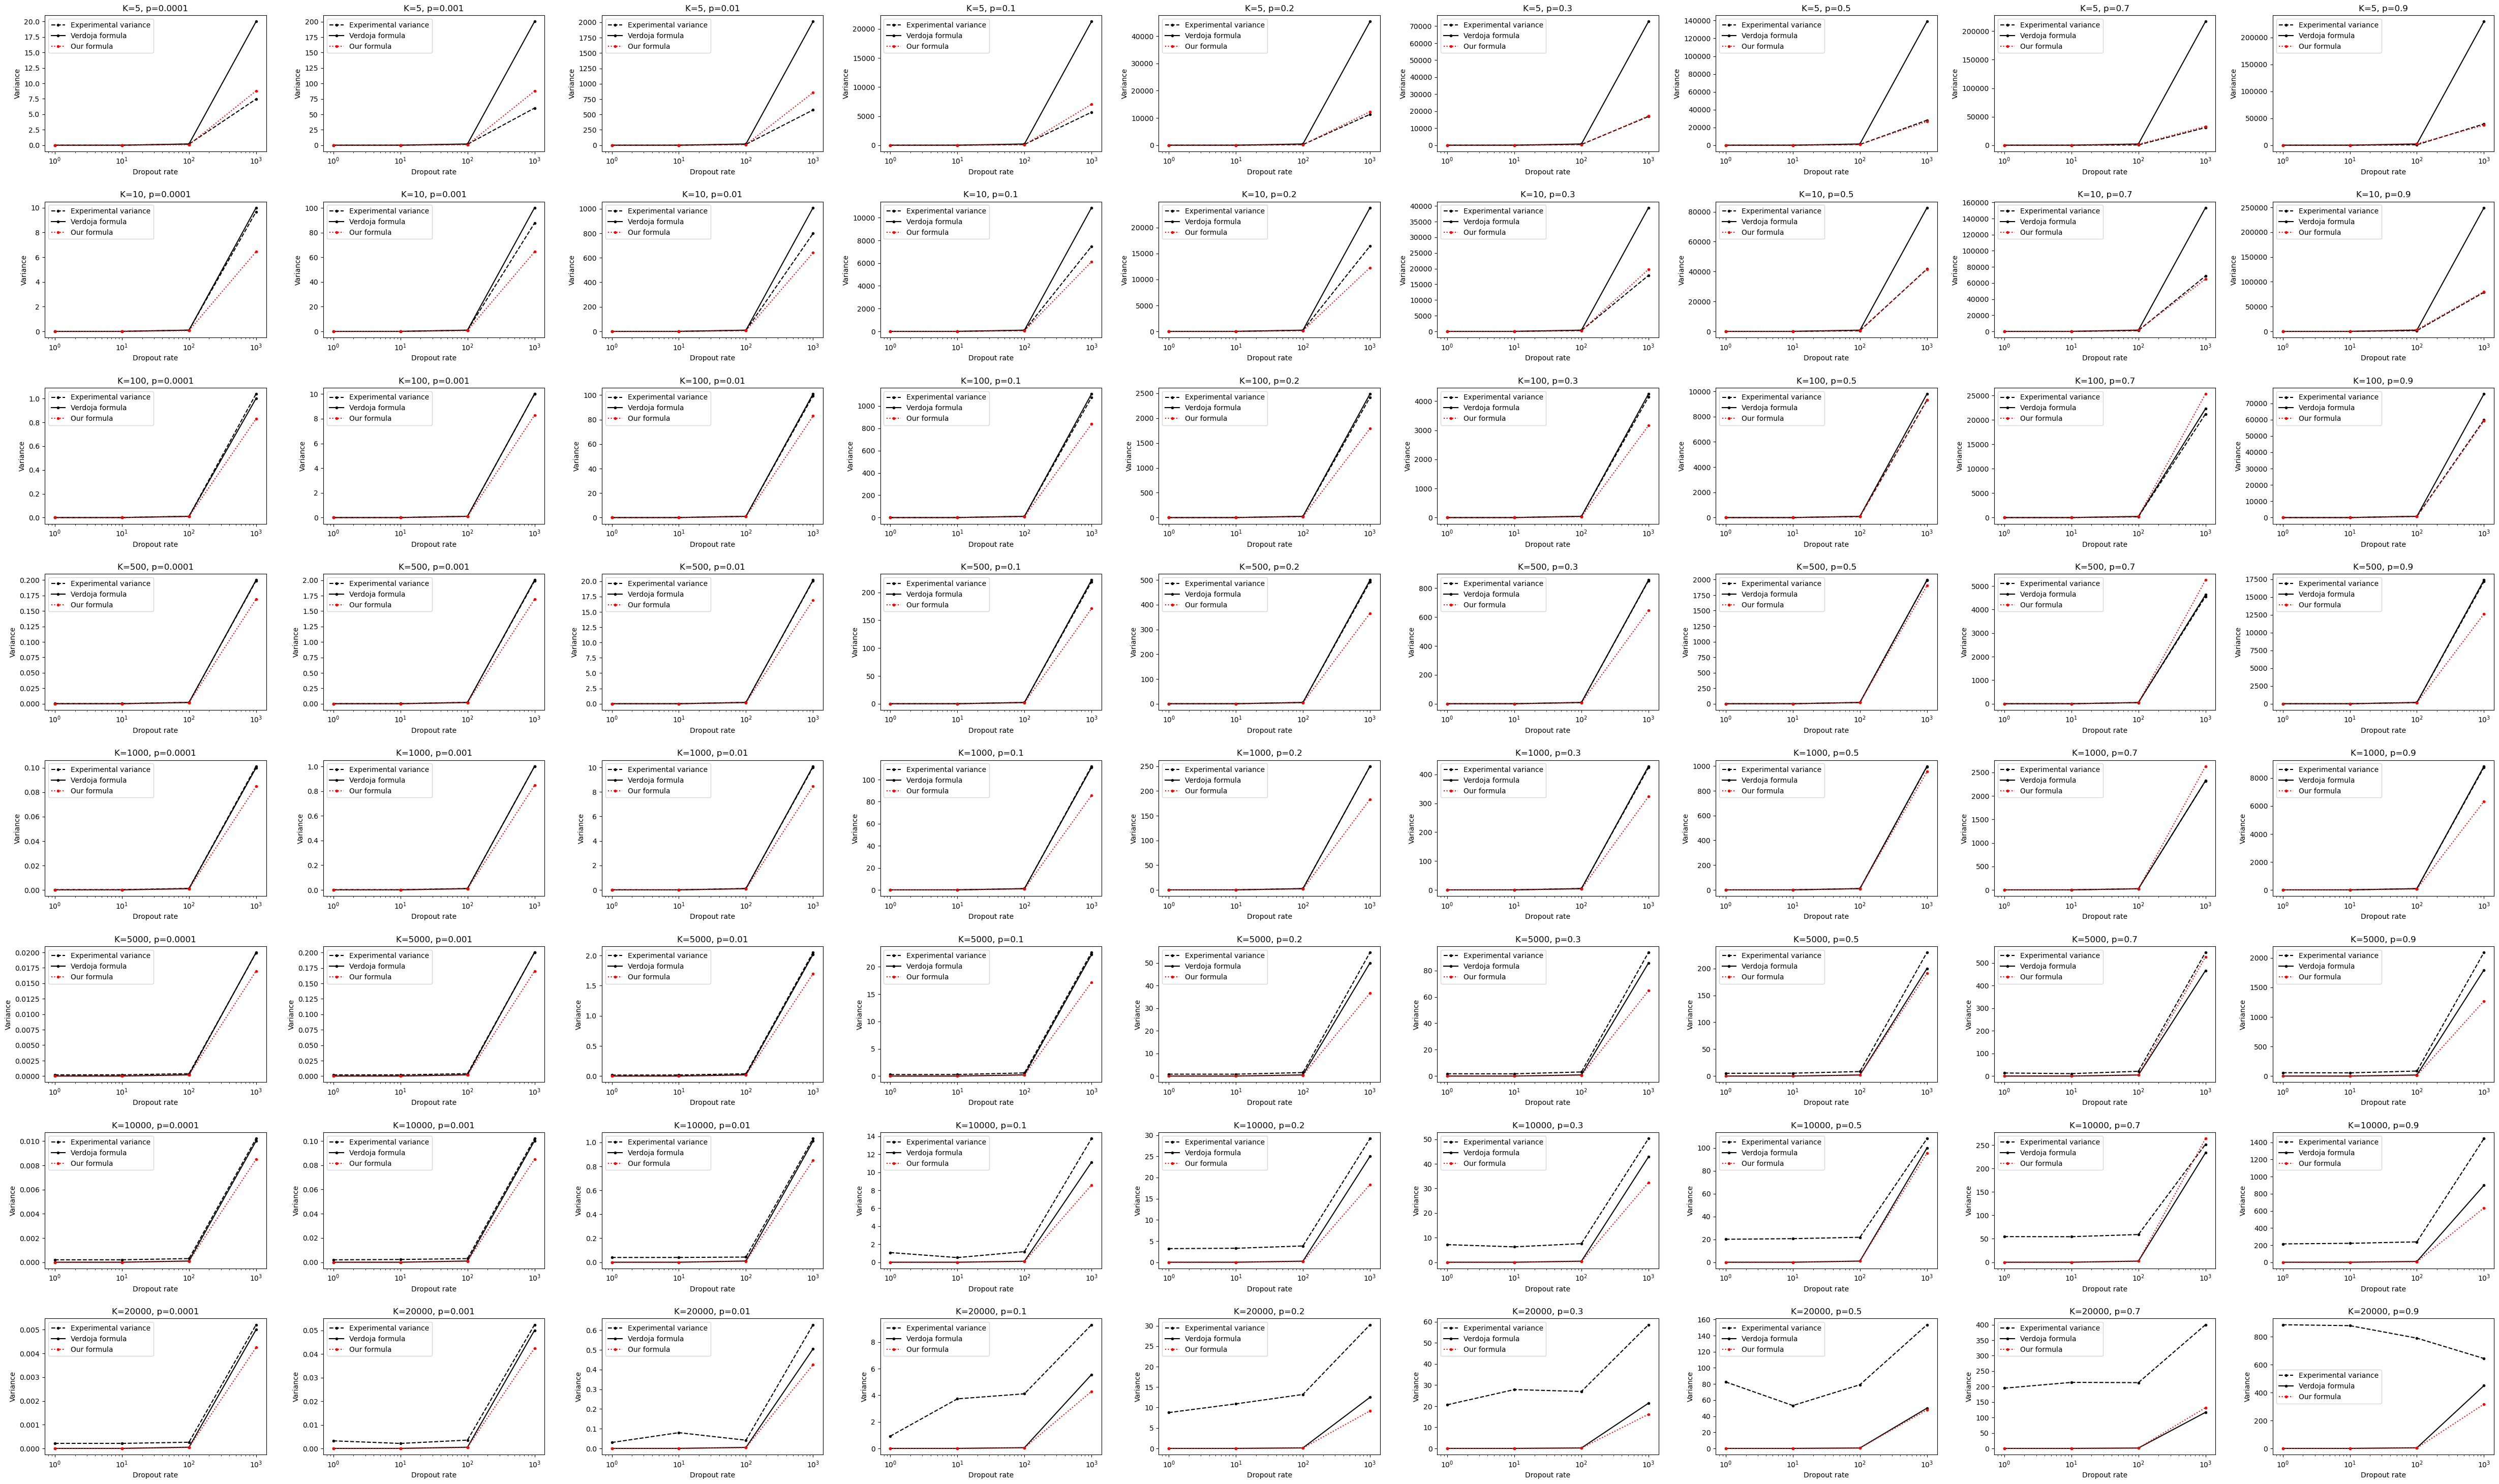

In [10]:
from pyparsing import line


fig, axes = plt.subplots(nrows=len(regression_data["K"].unique()), ncols=len(regression_data["p"].unique()), 
                         figsize=(50, 30))
fig.tight_layout(pad=5.0)

for i, K in enumerate(regression_data["K"].unique()):
    for j, p in enumerate(regression_data["p"].unique()):
        data_to_plot = regression_data[
            (regression_data["K"] == K) & (regression_data["p"] == p)
        ]
        x = data_to_plot["y_mean"]
        y = data_to_plot["variance"]
        y_verdoja = data_to_plot["variance_verdoja"]
        y_our_formula = data_to_plot["our_formula"]

        ax = axes[i, j]
        ax.plot(x, y, label="Experimental variance", marker=".", linestyle="--", color='black')
        ax.plot(x, y_verdoja, label="Verdoja formula", marker=".", linestyle="-", color='black')
        ax.plot(x, y_our_formula, label="Our formula", marker=".", linestyle=":", color='red')
        ax.set_xlabel("Dropout rate")
        ax.set_ylabel("Variance")
        ax.set_title(f"K={K}, p={p}")
        # set log axis
        ax.set_xscale('log')
        ax.legend()
plt.savefig("./symbolic_regression_verdoja/uncertainty_comparison_symbolic_ymean.pdf", bbox_inches='tight')
plt.show()


# Addestramento con numero diverso di epoche

Abbiamo una teoria che, sebbene il modello riesca a giungere a convergenza per quanto riguarda la predizione della media, non riesce a convergere per quanto riguarda la varianza. Ovvero, nel valore di varianza sperimentale, rimarrebbe una traccia (anche importante) di "varianza di convergenza". Al fine di testare questa ipotesi, addestriamo il modello, con gli stessi valori di $K$, $\overline{y}$ e $p_d$ (in un contesto dove sappiamo che il valore teorico sia corretto).

In [11]:
from joblib import Parallel, delayed
# NOTE: I am using the same dropout rates as I plan later
p = 0.1
K = 1000
y_mean = 2
batch_size = 16
num_mcdropout: int = int(1e5)
# num_epochs_list = [1, 2, 5, 6, 7, 8, 9, 10, 15, 20, 30, 40, 50, 100, 200, 300, ]
num_epochs_list = [1, 2, 3, 4, 7, 10, 50, 75, 100]

dataset = datasets[(K, y_mean)]
dataset_val = datasets_val[(K, y_mean)]

fn_input = [
    (dataset, dataset_val, K, y_mean, p, num_mcdropout, num_epochs, batch_size)
    for num_epochs in num_epochs_list
]
fn_outputs = Parallel(n_jobs=9)(delayed(run_dropout_estimation)(val) for val in fn_input)
# fn_outputs = [run_dropout_estimation(args) for args in tqdm(fn_input, desc='Epochs progress', colour='green')]

  2%|▏         | 1685/100000 [00:14<14:22, 114.04it/s]










Calcola log likelihood, e vedi come va. Fai lo stesso per R^2 e cosine similarity.

The log likelihood is a good estimate for how the model is doing at predicting uncertainty. It can be estimated from the validation set (in our case, $N=1$, so $j = 1$ and the equation is simplified) and using MCDropout as:
$$
L_j = \log{\left(\sum_{i=1}^T\left(e^{\frac 1 2 \tau \left(y_j - f_i(x_j)\right)^2}\right)\right)} - \log{T} - \frac 1 2 \log(2\pi) + \frac 1 2 \log{\tau}
$$

The variable $tau$ defines how much homoskedastic noise is there in the data. It is a parameter that can be used to control the $L_2$-regularization as well. In our formulation of the training, we use a parameter $\alpha$ for the formulation, and we set $\alpha=0.05$ (pretty strong regularization). To get $\tau$, we can use the formula:
$$
\tau = \frac{1}{2\alpha}
$$

In [18]:
true_variance = dataset_val["val"][1].var()

In [19]:
true_variance

0.9869985873963406

In [ ]:
from sklearn.metrics import mean_squared_error
from joblib import Parallel, delayed
from tqdm.auto import tqdm

N = 3200
l2 = 0.0001**2
p = 0.3
alpha = 0.0005
tau = l2 * (1 - p) / (alpha * 2 * N)
print(f"{tau=}")


def log_likelihood(y_true, y_pred, tau):
    return (
        np.log(-0.5 * tau * np.sum((y_true - y_pred) ** 2))
        - np.log(len(y_pred))
        - 0.5 * np.log(2 * np.pi)
        + 0.5 * np.log(tau)
    )


variances_epochs: dict[tuple[int, int, float], float] = {}


def get_metrics(num_epochs, mc_predictions):
    return (
        np.asarray(mc_predictions).var(),
        np.asarray(mc_predictions).mean(),
        (np.mean(y_mean - np.asarray(mc_predictions).mean(axis=0)) ** 2
        / true_variance),
        log_likelihood(
            y_mean,
            np.asarray(mc_predictions),
            tau,
        ),
    )


variances_epochs = {
    num_epochs: get_metrics(num_epochs, mc_predictions)
    for (_, _, _, mc_predictions), num_epochs in tqdm(
        zip(fn_outputs, num_epochs_list), total=len(fn_outputs))
}

tau=2.1874999999999997e-09


  0%|          | 0/9 [00:00<?, ?it/s]

In [21]:
variances_epochs = pd.DataFrame.from_dict(variances_epochs, 
                                          orient='index', 
                                          columns=['variance', 
                                                   'mean', 
                                                   'nmse',
                                                   'log likelihood'])

In [22]:
variances_epochs

,variance,mean,nmse,log likelihood
1,0.215510,1.401550,0.362860,-24.007358
2,0.208746,1.613840,0.151084,-24.479224
3,0.199949,1.840662,0.025723,-24.941785
4,0.193911,2.821391,0.683570,-23.592506
7,0.163141,2.101067,0.010349,-25.204037
10,0.139525,2.212466,0.045736,-25.140828
50,0.027444,2.261669,0.069373,-25.795920
75,0.023208,2.272790,0.075395,-25.778277
100,0.024345,2.131863,0.017617,-26.628081


In [9]:
variances_epochs

,variance,mean,nmse,log likelihood
1,0.223513,1.913907,0.007510,-24.917287
2,0.212644,1.590677,0.169752,-24.418714
3,0.200536,2.129325,0.016945,-24.978281
4,0.189546,2.249535,0.063088,-24.830691
7,0.153913,1.423940,0.336216,-24.173672
10,0.126290,1.972653,0.000758,-25.514900
50,0.013501,1.817428,0.033772,-26.512779
75,0.009710,1.770830,0.053211,-26.228557
100,0.011459,1.954473,0.002100,-27.754337


y_var_changed=0.0017128172705975404


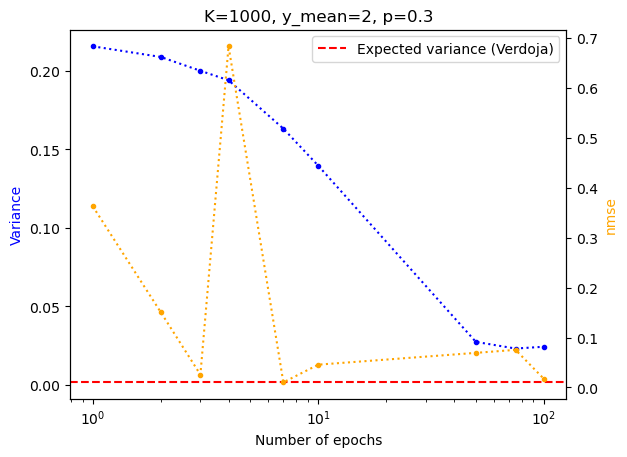

In [17]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Number of epochs')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

y_var_changed = (K * p * (1 - p) * (y_mean**2)) / ((K - K * p + p) ** 2)
print(f"{y_var_changed=}")
plt.axhline(y=y_var_changed, color='r', linestyle='--', label='Expected variance (Verdoja)')
plt.legend()
ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['nmse'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('nmse', color='orange')


# plt.axhline(y=y_mean, color='g', linestyle='--', label='Expected mean')


plt.title(f"{K=}, {y_mean=}, {p=}")
plt.savefig(f"./symbolic_regression_verdoja/epochs_analysis_{K=}_{y_mean=}_{p=}.pdf", bbox_inches='tight')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


y_var_changed=0.016996857604778547


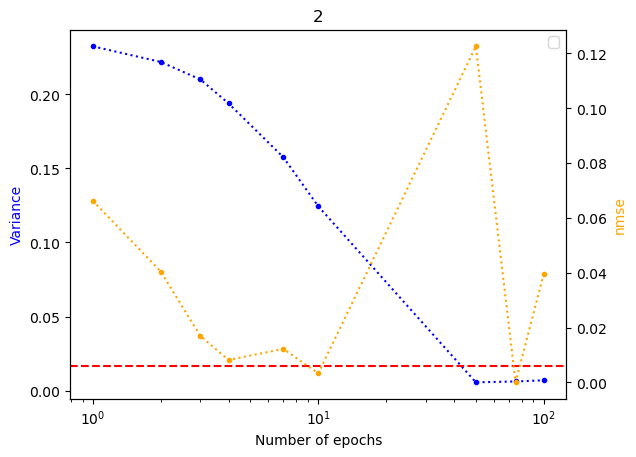

In [10]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Number of epochs')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

y_var_changed = (K * p * (1 - p) * (y_mean**2)) / ((K - K * p + p) ** 2)
print(f"{y_var_changed=}")
plt.axhline(y=y_var_changed, color='r', linestyle='--', label='Expected variance (Verdoja)')

ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['nmse'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('nmse', color='orange')


# plt.axhline(y=y_mean, color='g', linestyle='--', label='Expected mean')

plt.legend()
plt.title(y_mean)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


y_var_changed=0.016996857604778547


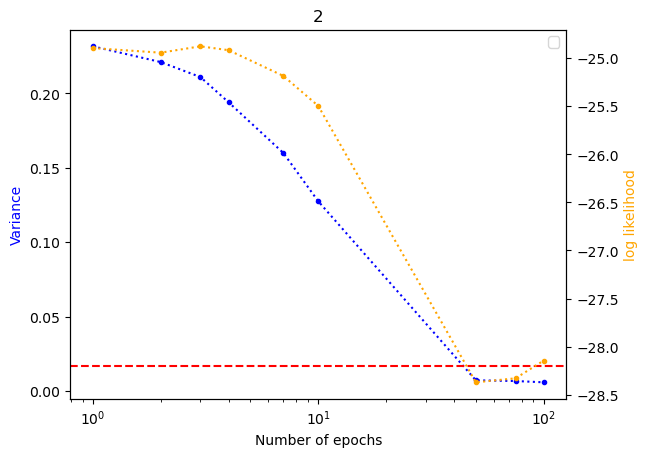

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [12]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Number of epochs')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

y_var_changed = (K * p * (1 - p) * (y_mean**2)) / ((K - K * p + p) ** 2)
print(f"{y_var_changed=}")
plt.axhline(y=y_var_changed, color='r', linestyle='--', label='Expected variance (Verdoja)')

ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['log likelihood'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('log likelihood', color='orange')


# plt.axhline(y=y_mean, color='g', linestyle='--', label='Expected mean')

plt.legend()
plt.title(y_mean)
plt.show()

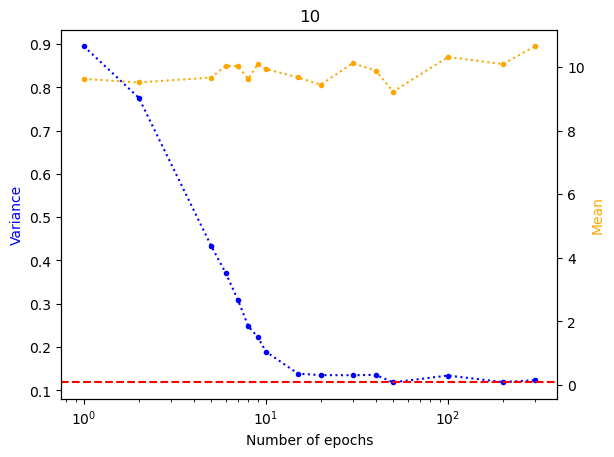

In [8]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Number of epochs')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['mean'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('Mean', color='orange')

y_var_changed = (K * p * (1 - p) * (y_mean**2)) / ((K - K * p + p) ** 2)
plt.axhline(y=y_var_changed, color='r', linestyle='--', label='Expected variance (Verdoja)')

plt.title(y_mean)
plt.show()

In [ ]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Number of epochs')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['mean'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('Mean', color='orange')

y_var_changed = (K * p * (1 - p) * (y_mean**2)) / ((K - K * p + p) ** 2)
plt.axhline(y=y_var_changed, color='r', linestyle='--', label='Expected variance (Verdoja)')

plt.title(y_mean)
plt.show()

# Training with various batch sizes

In [62]:
# NOTE: I am using the same dropout rates as I plan later
p = 0.3
K = 500
y_mean = 500
num_epochs = 100
num_mcdropout: int = int(1e5)
batch_sizes = [1, 2, 3, 4, 5, 6, 7, 8, 10, 16, 20, 32, 48, 64, 128, 256, 512, 1024, 2048, 2500, 3000]

dataset = datasets[(K, y_mean)]

fn_input = [(dataset, K, y_mean, p, num_mcdropout, num_epochs, batch_size) for batch_size in batch_sizes]
fn_outputs = process_map(run_dropout_estimation, fn_input, max_workers=9)

  0%|          | 0/21 [00:00<?, ?it/s]

In [63]:
variances_epochs: dict[tuple[int, int, float], float] = {}
variances_epochs = {
            (num_epochs): (np.asarray(mc_predictions).var(), np.asarray(mc_predictions).mean())
            for (_,_,_, mc_predictions), num_epochs in zip(fn_outputs, batch_sizes)
        }

In [64]:
variances_epochs = pd.DataFrame.from_dict(variances_epochs, orient='index', columns=['variance', 'mean'])

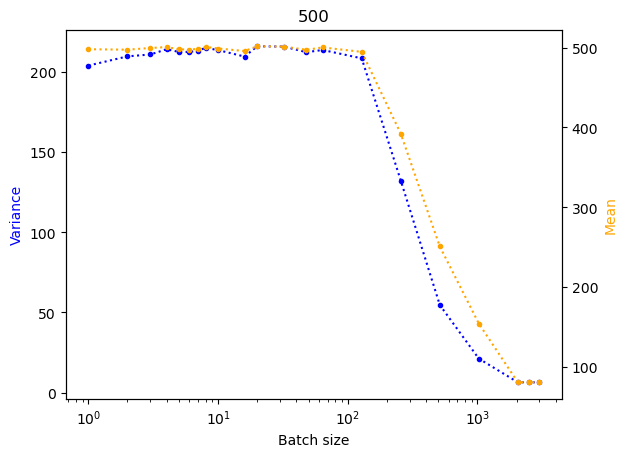

In [65]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Batch size')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['mean'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('Mean', color='orange')

plt.title(y_mean)
plt.show()

In [38]:
# variances_epochs = variances_epochs[variances_epochs['mean'] > 990]

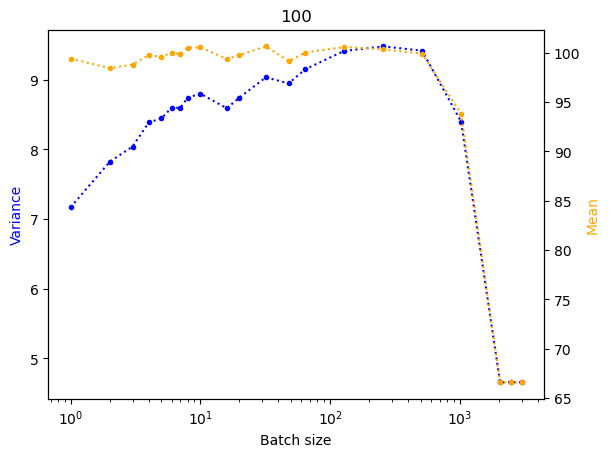

In [60]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Batch size')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['mean'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('Mean', color='orange')

plt.title(y_mean)
plt.show()

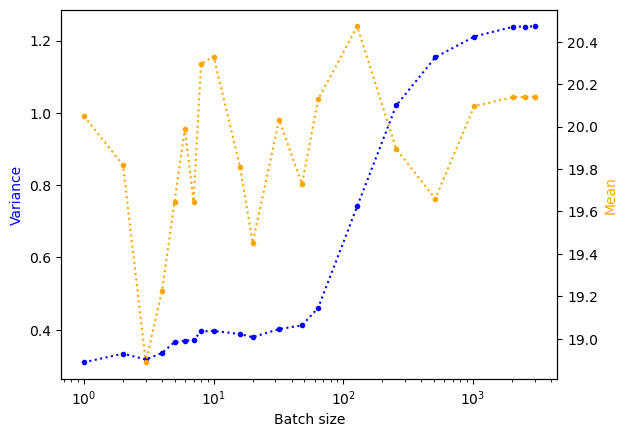

In [55]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Batch size')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['mean'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('Mean', color='orange')

plt.show()

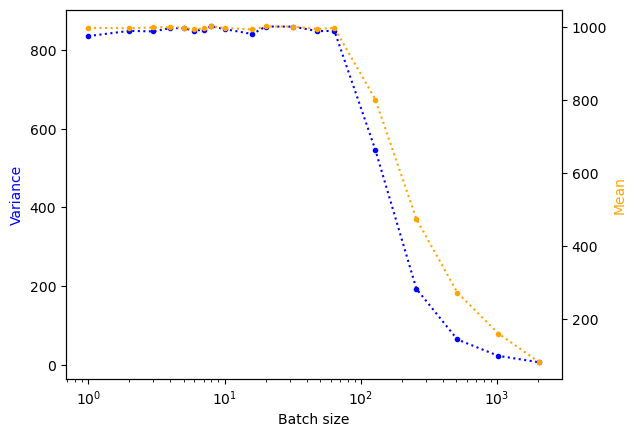

In [34]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Batch size')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['mean'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('Mean', color='orange')

plt.show()

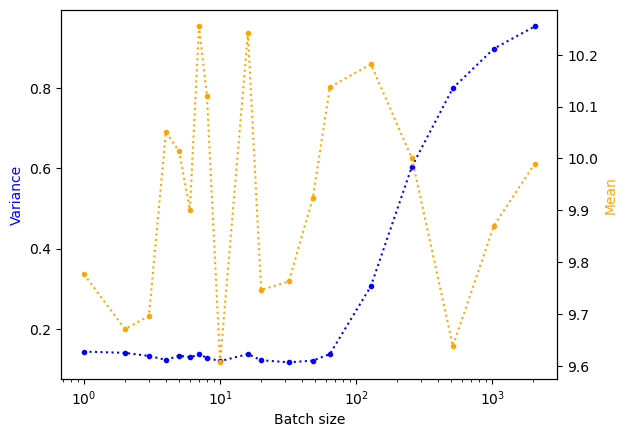

In [42]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Batch size')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['mean'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('Mean', color='orange')

plt.show()

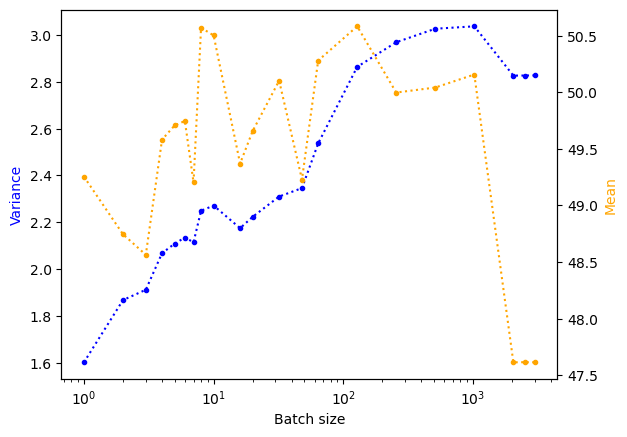

In [50]:
# make a dual axis plot
fig, ax1 = plt.subplots()

plt.plot(variances_epochs.index, variances_epochs['variance'], marker='.', linestyle=":", color='blue')
ax1.set_xlabel('Batch size')
# set x axis log
ax1.set_xscale('log')
ax1.set_ylabel('Variance', color='blue')

ax2 = ax1.twinx()
plt.plot(variances_epochs.index, variances_epochs['mean'], marker='.', linestyle=":", color='orange')
ax2.set_ylabel('Mean', color='orange')

plt.show()

# Calcolo Log Likelihood

**Notes on model training**. According to Gal, the training of a model with MCDropout should also contain a regularization term, $tau$, which he calls "model precision". And, indeed, the correct variance should also contain this term! He also suggests to optimize the model in order to find the best value for this parameter. In the experiments above, which are the same as the experiments performed by Vardoja, we did not consider this parameter. This is the same as setting $tau = 1$.

I